# Recurrent Neural Networks

            ## 1. Learning objectives

            - Implement a recurrent state update
- Track batch, time, and hidden dimensions
- Train an RNN for next-step prediction

            ## 2. Prerequisites

            NumPy arrays, matrix multiplication, basic derivatives, and the supervised-learning workflow.

In [1]:
from pathlib import Path
import sys

project_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.notebook_utils import RANDOM_SEED, set_seed
from src.plotting import COURSE_COLORS, set_course_style

set_seed(RANDOM_SEED)
set_course_style()
rng = np.random.default_rng(RANDOM_SEED)
print(f"Python lesson ready; reproducible seed = {RANDOM_SEED}")


import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

torch.set_num_threads(1)
device = torch.device("cpu")
print("PyTorch:", torch.__version__, "| device:", device)

Python lesson ready; reproducible seed = 42
PyTorch: 2.14.0+cpu | device: cpu


## 3. Problem definition

            Process ordered observations while carrying information from earlier time steps.

            ## 4. Real-world use cases

            - Image recognition
- Sequence modeling
- Learned feature representations

            ## 5. Core intuition in simple language

            The hidden state is a running notebook: each new input edits the notebook before the next step arrives.

## 6. Mathematical foundation

            $$\mathbf{h}_t=\tanh(\mathbf{x}_tW_{xh}+\mathbf{h}_{t-1}W_{hh}+\mathbf{b}).$$

            **Every symbol:**

            - $\mathbf{x}_t$ is input at time t.
- $\mathbf{h}_{t-1}$ is prior state.
- $W_{xh},W_{hh}$ are learned weights.
- $\mathbf{b}$ is bias.
- $\mathbf{h}_t$ is new state.

            **Why the equation is needed:** Reusing the same update at every step supports variable-length ordered data.

            **Small numerical example:** If input contribution=.4 and recurrent contribution=.2, the state before tanh is .6 and tanh(.6)=.537.

            **Connection to Python:** nn.RNN performs this recurrence for all steps and batches.

## 7. Visual explanation

            The executable figure below is chosen to reveal the structure this method learns. Read positions and lengths first; color is a supporting cue rather than the only encoding.

            ## 8. Algorithm steps

            1. Create tensors with explicit batch and feature dimensions
2. Run a forward pass
3. Compute a loss against targets
4. Backpropagate gradients
5. Update parameters with an optimizer
6. Evaluate on untouched validation data

## 9. Implementation from scratch

NumPy exposes the forward calculation and, where appropriate, the gradients.

The simplified implementation exposes the central mechanism. It favors readability over production-scale numerical safeguards.

In [2]:
def rnn_step(x_t, h_previous, W_xh, W_hh, bias):
    return np.tanh(x_t @ W_xh + h_previous @ W_hh + bias)

sequence = np.array([[.1], [.2], [.3]])
h = np.zeros((1, 2))
W_xh = np.array([[.5, -.4]]); W_hh = np.eye(2)*.3; bias=np.zeros(2)
states=[]
for value in sequence:
    h=rnn_step(value[None,:],h,W_xh,W_hh,bias); states.append(h.copy())
print("Sequence/state shapes:", sequence.shape, np.array(states).shape)

Sequence/state shapes: (3, 1) (3, 1, 2)


## 10. Implementation using a standard library

PyTorch tensors, modules, autograd, losses, and optimizers provide the standard implementation.

## 11. Dataset loading and exploration

Every lesson uses a generated sequence or a small dataset bundled with scikit-learn; no download is required.

## 12. Data preprocessing

Splits occur before fitted transformations. Inputs are converted to float32 tensors and class labels to int64.

## 13. Model training

The next cell trains both the transparent and library-backed versions where the topic has a trainable model.

## 14. Predictions

Predictions, transformed representations, actions, or value estimates are kept in named arrays so their shapes can be inspected.

## 15. Evaluation

Evaluation uses a metric appropriate to the learning setting and always retains a simple baseline or reasonableness check.

## 16. Visualization of results

Every chart has a descriptive title and labeled axes. The interpretation immediately below describes what the marks mean.

Model diagnostics: {'input_shape': (170, 12, 1), 'intermediate_shapes': ((170, 12, 12), (1, 170, 12)), 'output_shape': (170, 1), 'trainable_parameters': 193, 'final_training_loss': 0.00072, 'final_validation_loss': 0.00072, 'validation_RMSE': 0.0268}


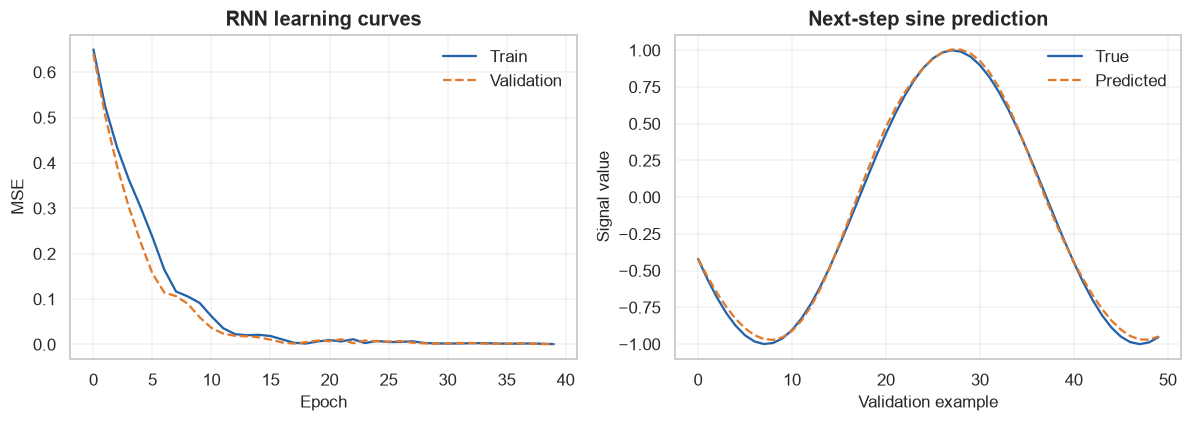

In [3]:
steps=240
signal=np.sin(np.linspace(0,12*np.pi,steps)).astype("float32")
window=12
X=np.stack([signal[i:i+window] for i in range(steps-window)])
y=np.array([signal[i+window] for i in range(steps-window)],dtype="float32")
split=170
train_X=torch.tensor(X[:split,:,None]); train_y=torch.tensor(y[:split,None])
validation_X=torch.tensor(X[split:,:,None]); validation_y=torch.tensor(y[split:,None])

class TinyRNN(nn.Module):
    def __init__(self):
        super().__init__(); self.rnn=nn.RNN(1,12,batch_first=True); self.output=nn.Linear(12,1)
    def forward(self,values):
        sequence_output,hidden=self.rnn(values)
        return self.output(sequence_output[:,-1]), sequence_output, hidden

model=TinyRNN(); optimizer=torch.optim.Adam(model.parameters(),lr=.02); loss_fn=nn.MSELoss()
train_losses=[]; validation_losses=[]
for epoch in range(40):
    model.train(); optimizer.zero_grad(); prediction,sequence_output,hidden=model(train_X)
    loss=loss_fn(prediction,train_y); loss.backward(); optimizer.step()
    model.eval()
    with torch.no_grad(): val_prediction,_,_=model(validation_X); val_loss=loss_fn(val_prediction,validation_y)
    train_losses.append(loss.item()); validation_losses.append(val_loss.item())
validation_rmse = float(torch.sqrt(loss_fn(val_prediction, validation_y)))
print("Model diagnostics:", {
    "input_shape": tuple(train_X.shape),
    "intermediate_shapes": (tuple(sequence_output.shape), tuple(hidden.shape)),
    "output_shape": tuple(prediction.shape),
    "trainable_parameters": sum(p.numel() for p in model.parameters()),
    "final_training_loss": round(train_losses[-1], 5),
    "final_validation_loss": round(validation_losses[-1], 5),
    "validation_RMSE": round(validation_rmse, 5),
})
figure,axes=plt.subplots(1,2,figsize=(11,4))
axes[0].plot(train_losses,label="Train",color=COURSE_COLORS["blue"]); axes[0].plot(validation_losses,label="Validation",color=COURSE_COLORS["orange"],linestyle="--")
axes[0].set(title="RNN learning curves",xlabel="Epoch",ylabel="MSE"); axes[0].legend()
axes[1].plot(validation_y.numpy()[:50],label="True",color=COURSE_COLORS["blue"]); axes[1].plot(val_prediction.numpy()[:50],label="Predicted",color=COURSE_COLORS["orange"],linestyle="--")
axes[1].set(title="Next-step sine prediction",xlabel="Validation example",ylabel="Signal value"); axes[1].legend()
figure.tight_layout(); plt.show()

**How to interpret the result:** The RNN learns short sine dynamics; divergence between train and validation loss would signal overfitting or distribution mismatch.

**Scratch-to-library comparison:**

- **Performance:** the educational implementation favors visible steps; the library implementation uses optimized, vectorized, and often compiled routines.
- **Numerical stability:** production libraries add convergence checks, guarded arithmetic, and tested handling of edge cases that the compact scratch version intentionally omits.
- **Flexibility:** scratch code is easy to inspect and change for one lesson, while the library version supports reusable estimator interfaces, pipelines, and broader input cases.
- **Complexity:** the scratch implementation makes the central mechanism explicit; the library hides additional validation and engineering complexity behind a small public API.

Compare the measured outputs above rather than expecting exact equality: initialization, stopping rules, regularization, and implementation details can differ.

## 17. Hyperparameter experiments

Window length controls available context but increases computation and can make gradient propagation harder.

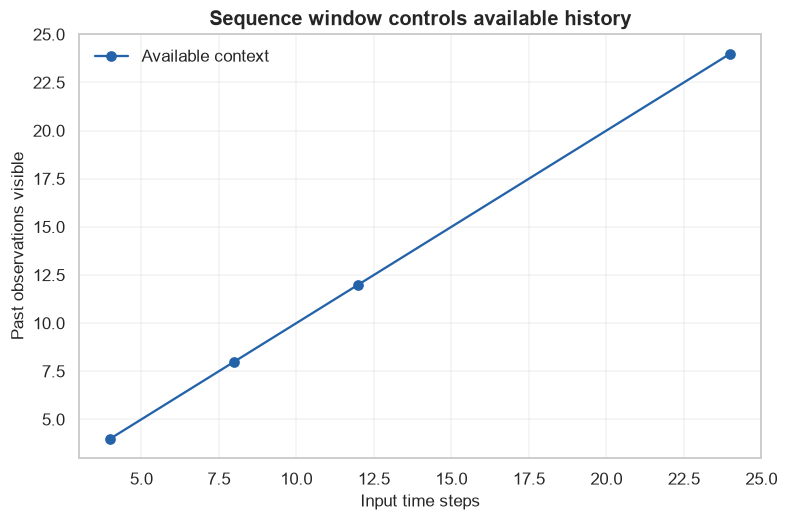

In [4]:
lengths=[4,8,12,24]
dependencies=np.array(lengths)
figure,axis=plt.subplots()
axis.plot(lengths,dependencies,marker="o",color=COURSE_COLORS["blue"],label="Available context")
axis.set(title="Sequence window controls available history",xlabel="Input time steps",ylabel="Past observations visible")
axis.legend(); plt.show()

## 18. Common mistakes

            - Forgetting batch and feature dimensions
- Applying softmax before CrossEntropyLoss
- Evaluating on the training set
- Leaving gradients accumulated between optimizer steps

            ## 19. Advantages and disadvantages

            **Advantages**

            - Learns features jointly with predictions
- Flexible building blocks for structured data

            **Disadvantages**

            - Needs careful optimization and validation
- Can be computationally expensive and difficult to interpret

            ## 20. When to use and when not to use the algorithm

            **Use it when:** the data and task benefit from learned nonlinear representations and validation supports the added complexity.

            **Do not use it when:** a small tabular dataset is handled well by a simpler, easier-to-audit model.

## 21. Exercises

1. **Conceptual:** Why do hidden layers need nonlinear activations?
2. **Mathematical/hand calculation:** Calculate ReLU([−2, 0, 3]).
3. **Coding/experimentation:** Double hidden width and compare parameter count and validation behavior.

<details>
<summary><strong>22. Exercise solutions</strong></summary>

1. Without nonlinearities, multiple affine layers equal one affine layer.
2. The result is [0, 0, 3].
3. Change the layer width, count parameters, retrain with the same split, and compare training-versus-validation loss rather than training loss alone.

</details>

## 23. Summary and key takeaways

            - Tensor shapes are part of the model specification
- Forward propagation produces predictions and backpropagation produces gradients
- Training and validation curves reveal optimization and generalization

            ## 24. Further reading

            - [PyTorch tutorials](https://pytorch.org/tutorials/)
- [PyTorch neural-network modules](https://pytorch.org/docs/stable/nn.html)